# **Simple Linear Model to Predict Financial Retruns**

**Importing Libraries & getting data**

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LinearRegression

In [31]:
company=["BSE.NS","IRCTC.NS","DIXON.NS"]
start_date="2026-01-05"
end_date="2026-01-09"
data=yf.download(company,start_date,end_date,interval="15m")
df=pd.DataFrame(data["Close"])
df

/tmp/ipython-input-2942448461.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(company,start_date,end_date,interval="15m")
[*********************100%***********************]  3 of 3 completed


Ticker,BSE.NS,DIXON.NS,IRCTC.NS
Datetime,,,
2026-01-05 03:45:00+00:00,2638.000000,12212.0,695.849976
2026-01-05 04:00:00+00:00,2620.300049,12134.0,694.250000
2026-01-05 04:15:00+00:00,2621.000000,12158.0,692.950012
2026-01-05 04:30:00+00:00,2633.899902,12209.0,690.299988
2026-01-05 04:45:00+00:00,2641.699951,12217.0,688.950012
...,...,...,...
2026-01-08 08:45:00+00:00,2696.699951,11946.0,655.250000
2026-01-08 09:00:00+00:00,2706.699951,12007.0,658.099976
2026-01-08 09:15:00+00:00,2715.300049,12004.0,661.000000


**Getting Log Returns and Lag1 columns**

In [32]:
# df_copy = df.copy()     # use this when you have to run only this cell apart from run all cell together.
LR = pd.DataFrame(index=df.index)
Lag_1=pd.DataFrame(index=df.index)
lm=LinearRegression(fit_intercept=True)
for ticker in df.columns:
  df[f"LR {ticker}"]=np.log(df[ticker]/df[ticker].shift(1))
  df[f"LR {ticker}"].dropna(inplace=True)
  LR[ticker]=df[f"LR {ticker}"]
  df[f"Lag 1 {ticker}"]=df[f"LR {ticker}"].shift(1)
  df[f"Lag 1 {ticker}"].dropna(inplace=True)
  Lag_1[ticker]=df[f"Lag 1 {ticker}"]
df

Ticker,BSE.NS,DIXON.NS,IRCTC.NS,LR BSE.NS,Lag 1 BSE.NS,LR DIXON.NS,Lag 1 DIXON.NS,LR IRCTC.NS,Lag 1 IRCTC.NS
Datetime,,,,,,,,,
2026-01-05 03:45:00+00:00,2638.000000,12212.0,695.849976,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-05 04:00:00+00:00,2620.300049,12134.0,694.250000,-0.006732,NaN,-0.006408,NaN,-0.002302,NaN
2026-01-05 04:15:00+00:00,2621.000000,12158.0,692.950012,0.000267,-0.006732,0.001976,-0.006408,-0.001874,-0.002302
2026-01-05 04:30:00+00:00,2633.899902,12209.0,690.299988,0.004910,0.000267,0.004186,0.001976,-0.003832,-0.001874
2026-01-05 04:45:00+00:00,2641.699951,12217.0,688.950012,0.002957,0.004910,0.000655,0.004186,-0.001958,-0.003832
...,...,...,...,...,...,...,...,...,...
2026-01-08 08:45:00+00:00,2696.699951,11946.0,655.250000,-0.002481,-0.003950,0.000921,-0.003847,-0.002287,-0.001750
2026-01-08 09:00:00+00:00,2706.699951,12007.0,658.099976,0.003701,-0.002481,0.005093,0.000921,0.004340,-0.002287
2026-01-08 09:15:00+00:00,2715.300049,12004.0,661.000000,0.003172,0.003701,-0.000250,0.005093,0.004397,0.004340


In [33]:
LR

,BSE.NS,DIXON.NS,IRCTC.NS
Datetime,,,
2026-01-05 03:45:00+00:00,NaN,NaN,NaN
2026-01-05 04:00:00+00:00,-0.006732,-0.006408,-0.002302
2026-01-05 04:15:00+00:00,0.000267,0.001976,-0.001874
2026-01-05 04:30:00+00:00,0.004910,0.004186,-0.003832
2026-01-05 04:45:00+00:00,0.002957,0.000655,-0.001958
...,...,...,...
2026-01-08 08:45:00+00:00,-0.002481,0.000921,-0.002287
2026-01-08 09:00:00+00:00,0.003701,0.005093,0.004340
2026-01-08 09:15:00+00:00,0.003172,-0.000250,0.004397


**Simple Linear Model to Predict Financial Returns**

In [50]:
df.dropna(inplace=True)
lm=LinearRegression(fit_intercept=True)
lm.fit(df["Lag 1 BSE.NS"].to_frame(),df["LR BSE.NS"])

LinearRegression()

In [47]:
slope=lm.coef_
slope

array([-0.00037685])

In [49]:
intercept=lm.intercept_
intercept

np.float64(0.00029448373755939556)

In [53]:
df["Predict BSE.NS"]=lm.predict(df["Lag 1 BSE.NS"].to_frame())
df["Predict BSE.NS"]

,Predict BSE.NS
Datetime,
2026-01-05 04:15:00+00:00,0.000297
2026-01-05 04:30:00+00:00,0.000294
2026-01-05 04:45:00+00:00,0.000293
2026-01-05 05:00:00+00:00,0.000293
2026-01-05 05:15:00+00:00,0.000293
...,...
2026-01-08 08:45:00+00:00,0.000296
2026-01-08 09:00:00+00:00,0.000295
2026-01-08 09:15:00+00:00,0.000293


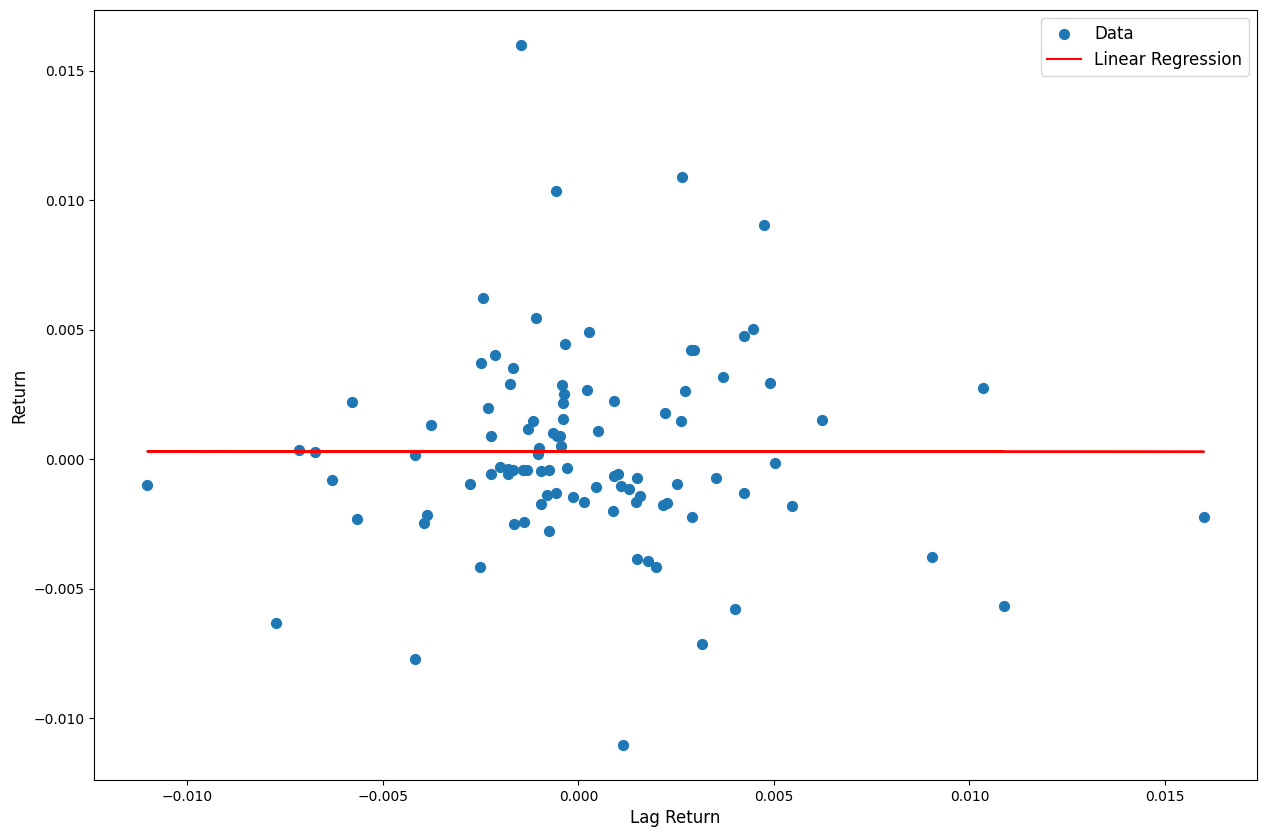

In [56]:
plt.figure(figsize=(15,10))
plt.scatter(x=df['Lag 1 BSE.NS'],y=df['LR BSE.NS'],s=50,label="Data")
plt.plot(df['Lag 1 BSE.NS'],df["Predict BSE.NS"],label="Linear Regression",c="red")
plt.legend(fontsize=12)
plt.xlabel("Lag Return",fontsize=12)
plt.ylabel("Return",fontsize=12)
plt.show()

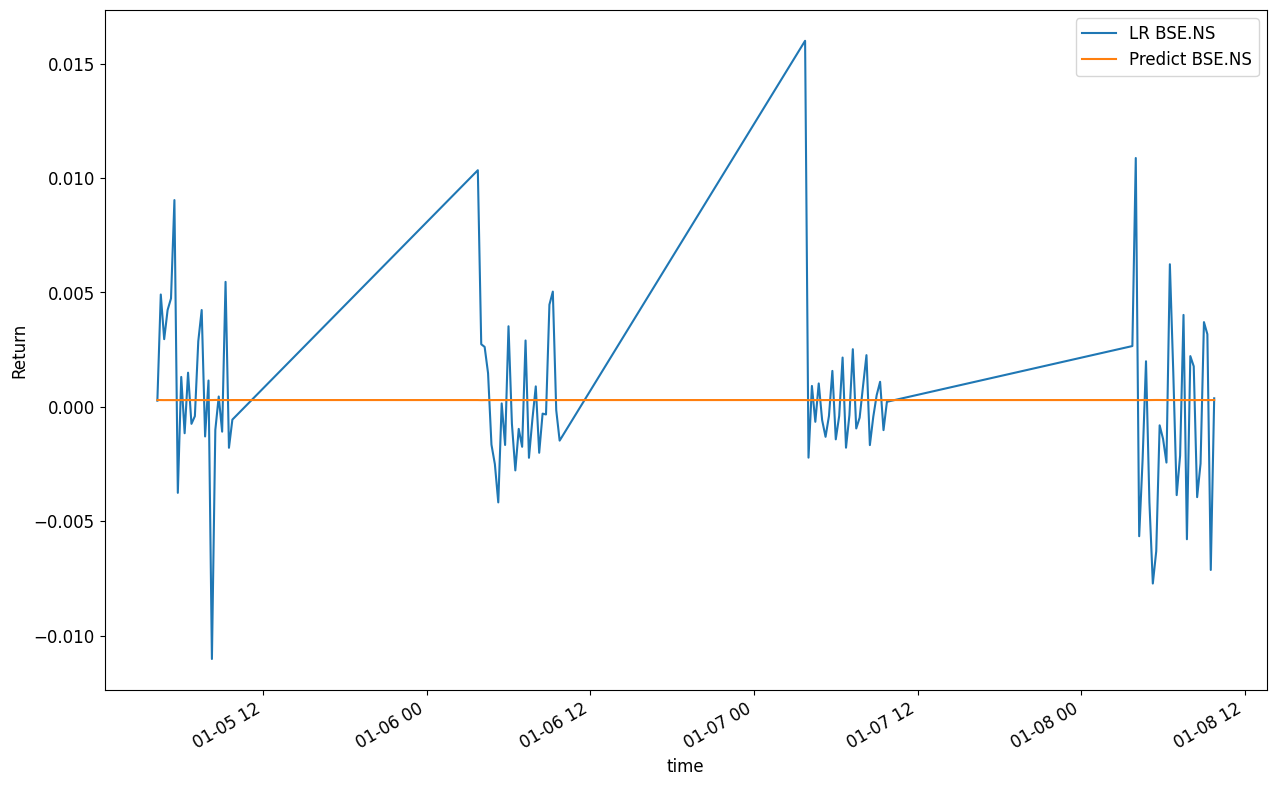

In [57]:
df[["LR BSE.NS","Predict BSE.NS"]].plot(figsize=(15,10),fontsize=12)
plt.legend(fontsize=12)
plt.xlabel("time",fontsize=12)
plt.ylabel("Return",fontsize=12)
plt.show()